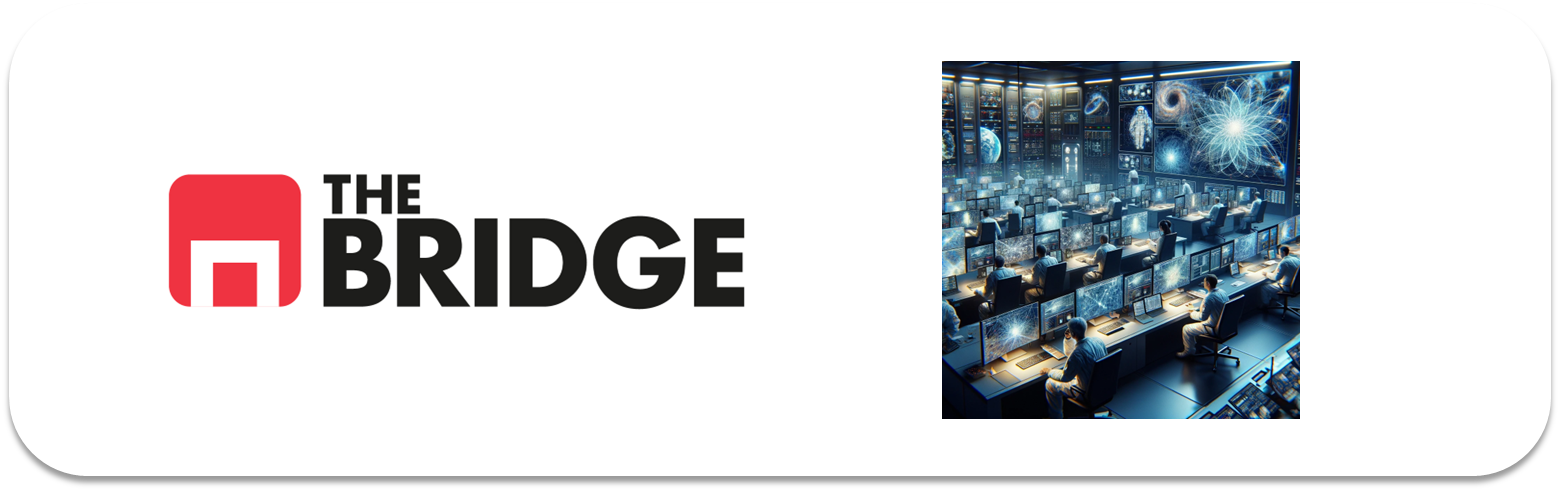

## PRACTICA OBLIGATORIA: **Transfer Learning y Fine Tuning con CNN**

* La práctica obligatoria de esta unidad consiste en un repetir el ejercicio de construcción de un modelo de clasificación de paisajes pero usando un modelo preentrenado. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0
GPU: []


### Objetivo del ejercicio

Comparar una red convolucional hecha ad-hoc frente a los modelos preentrenados y ajustados con fine tuning y transfer learning. Para ello emplea el dataset de paisajes del conjunto de ejercicios de la unidad anterior.


### Se pide

1. Preparar los datos del modelo y las funciones de visualización, copia para ello todo lo que necesites de las soluciones del ejercicio de clasificación de paisajes de la unidad anterior.

2. Escoger entre uno de los modelos VGG-19, InceptionV3 y MobileNetV2 (todos en https://keras.io/api/applications/) (Se aconseja este último si no tenemos un ordenador muy potente). Si no te haces con estos puedes recurrir a la ResNetV50.

4. Hacer un transfer-learning con una cabeza de como mucho 2 capas densas ocultas y una de salida. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

5. Hacer un fine-tuning con la misma cabeza diseñada en el punto anterior. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

6. Comparar los resultados con los obtenidos con la red convolucional del ejercicio mencionado.

EXTRA:
- Repetir el transfer learning empleando aumentado de imágenes.



## 1. Preparación del dataset

In [2]:
DATA_DIR = 'data'

train_folders = [
    'github_train_0',
    'github_train_1',
    'github_train_2',
    'github_train_3'
]

test_folder = 'github_test'

### Función para crear DataFrame con rutas y etiquetas

In [3]:
def build_dataframe(folder_path):
    images = []
    labels = []
    for file in os.listdir(folder_path):
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            name = file.lower()
            if name.startswith('cat'):
                labels.append('cat')
            elif name.startswith('dog'):
                labels.append('dog')
            else:
                continue
            images.append(os.path.join(folder_path, file))
    return pd.DataFrame({'filename': images, 'label': labels})

# Construir DataFrame de train (uniendo las 4 carpetas)
train_dfs = [build_dataframe(os.path.join(DATA_DIR, f)) for f in train_folders]
df_train_full = pd.concat(train_dfs, ignore_index=True)

# DataFrame de test
df_test = build_dataframe(os.path.join(DATA_DIR, test_folder))

print(f'Total imágenes train+val : {len(df_train_full)}')
print(f'Total imágenes test      : {len(df_test)}')
print('\nDistribución train+val:')
print(df_train_full['label'].value_counts())
print('\nDistribución test:')
print(df_test['label'].value_counts())

Total imágenes train+val : 4000
Total imágenes test      : 1000

Distribución train+val:
label
cat    2000
dog    2000
Name: count, dtype: int64

Distribución test:
label
cat    500
dog    500
Name: count, dtype: int64


 ### Split train / validación

In [4]:
from sklearn.model_selection import train_test_split

df_train, df_val = train_test_split(
    df_train_full,
    test_size=0.15,
    random_state=42,
    stratify=df_train_full['label']
)

df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)

print(f'Train      : {len(df_train)} imágenes')
print(f'Validación : {len(df_val)} imágenes')
print(f'Test       : {len(df_test)} imágenes')

Train      : 3400 imágenes
Validación : 600 imágenes
Test       : 1000 imágenes


### Generadores de imágenes

In [5]:
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32
SEED       = 42

datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_dataframe(
    df_train,
    x_col='filename',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    seed=SEED
)

val_gen = datagen.flow_from_dataframe(
    df_val,
    x_col='filename',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_gen = datagen.flow_from_dataframe(
    df_test,
    x_col='filename',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

CLASS_NAMES = list(train_gen.class_indices.keys())
print('Clases:', train_gen.class_indices)

Found 3400 validated image filenames belonging to 2 classes.
Found 600 validated image filenames belonging to 2 classes.
Found 1000 validated image filenames belonging to 2 classes.
Clases: {'cat': 0, 'dog': 1}


### Funciones de visualización

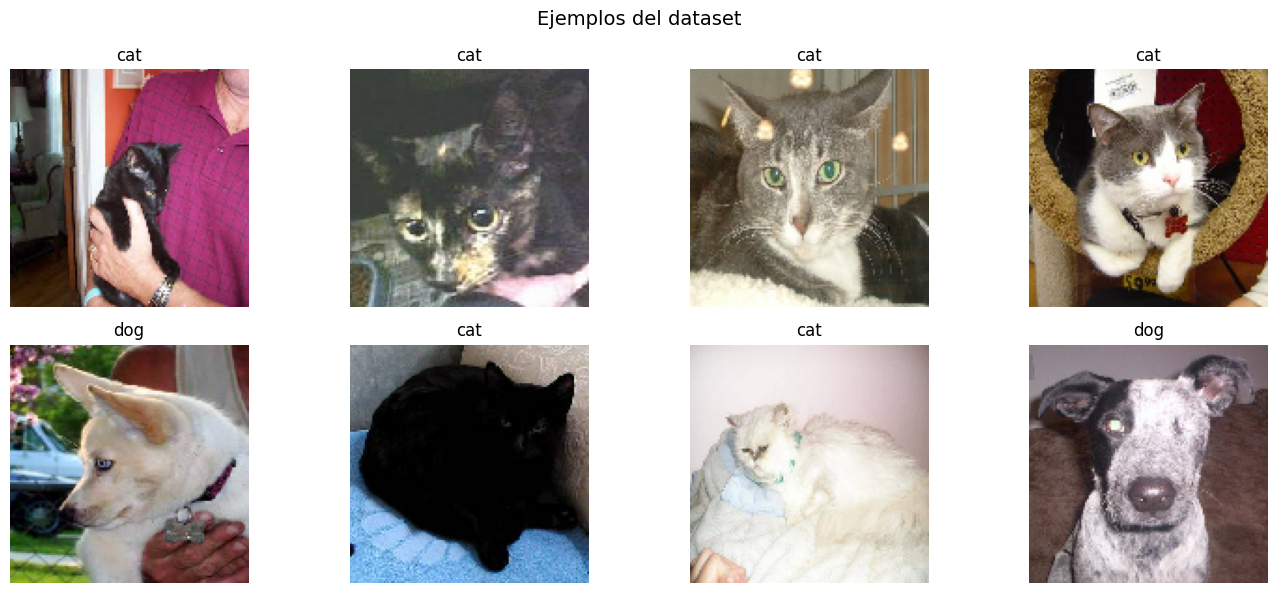

In [6]:
def show_sample_images(generator, class_names, n=8):
    imgs, labels = next(generator)
    fig, axes = plt.subplots(2, 4, figsize=(14, 6))
    for i, ax in enumerate(axes.flat):
        if i < n:
            ax.imshow(imgs[i])
            ax.set_title(class_names[int(labels[i])], fontsize=12)
        ax.axis('off')
    plt.suptitle('Ejemplos del dataset', fontsize=14)
    plt.tight_layout()
    plt.show()

def plot_history(history, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history.history['accuracy'],     label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Validación')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('Época'); axes[0].legend(); axes[0].grid(True)
    axes[1].plot(history.history['loss'],     label='Train')
    axes[1].plot(history.history['val_loss'], label='Validación')
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('Época'); axes[1].legend(); axes[1].grid(True)
    plt.tight_layout()
    plt.show()

def evaluate_model(model, generator, class_names, title=''):
    generator.reset()
    loss, acc = model.evaluate(generator, verbose=0)
    print(f'\n── {title} ──')
    print(f'  Loss : {loss:.4f}')
    print(f'  Acc  : {acc:.4f}')
    generator.reset()
    y_pred_probs = model.predict(generator, verbose=0)
    y_pred = (y_pred_probs > 0.5).astype(int).flatten()
    y_true = generator.classes
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=class_names))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Matriz de Confusión — {title}')
    plt.ylabel('Real'); plt.xlabel('Predicho')
    plt.tight_layout(); plt.show()
    return loss, acc

show_sample_images(train_gen, CLASS_NAMES)

## 2. Modelo CNN ad-hoc (referencia)

Red convolucional propia para tener una línea base de comparación.

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D

model_cnn = Sequential([
    tf.keras.Input(shape=IMG_SIZE + (3,)),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
], name='CNN_adhoc')

model_cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_cnn.summary()

Model: "CNN_adhoc"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 248s 2s/step - accuracy: 0.5462 - loss: 0.6886 - val_accuracy: 0.5550 - val_loss: 0.6733 - learning_rate: 0.0010
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 227s 2s/step - accuracy: 0.5909 - loss: 0.6572 - val_accuracy: 0.5917 - val_loss: 0.6615 - learning_rate: 0.0010
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 214s 2s/step - accuracy: 0.6212 - loss: 0.6419 - val_accuracy: 0.5850 - val_loss: 0.6558 - learning_rate: 0.0010
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 273s 2s/step - accuracy: 0.6285 - loss: 0.6355 - val_accuracy: 0.6083 - val_loss: 0.6474 - learning_rate: 0.0010
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.6279 - loss: 0.6323 - val_accuracy: 0.6183 - val_loss: 0.6555 - learning_rate: 0.0010
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 87s 805ms/step - accuracy: 0.6347 - loss: 0.6217 - val_accuracy: 0.6267 - val_loss: 0.6359 - learning_rate: 0.0010
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - accuracy: 0.6421 - loss: 

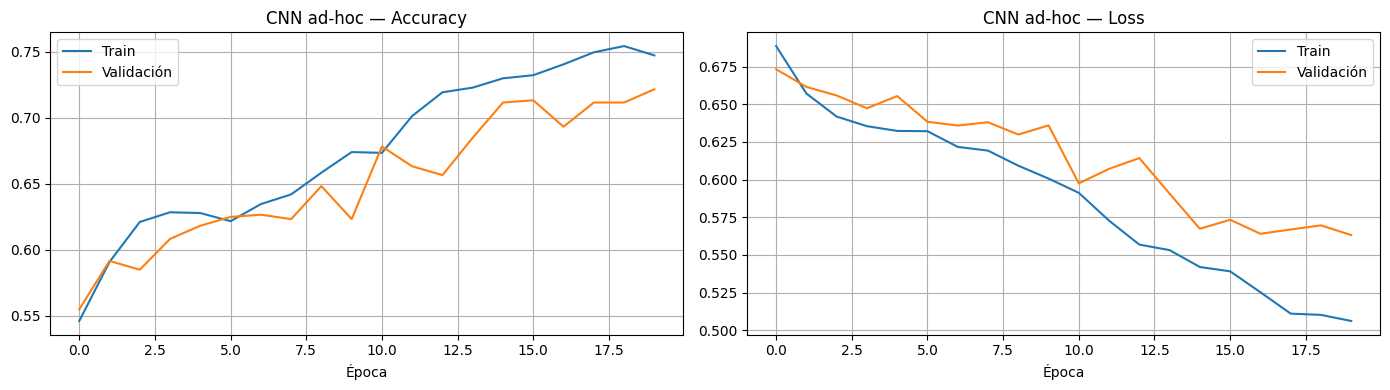


── CNN ad-hoc — Test ──
  Loss : 0.5623
  Acc  : 0.7190

Classification Report:
              precision    recall  f1-score   support

         cat       0.73      0.70      0.71       500
         dog       0.71      0.74      0.72       500

    accuracy                           0.72      1000
   macro avg       0.72      0.72      0.72      1000
weighted avg       0.72      0.72      0.72      1000



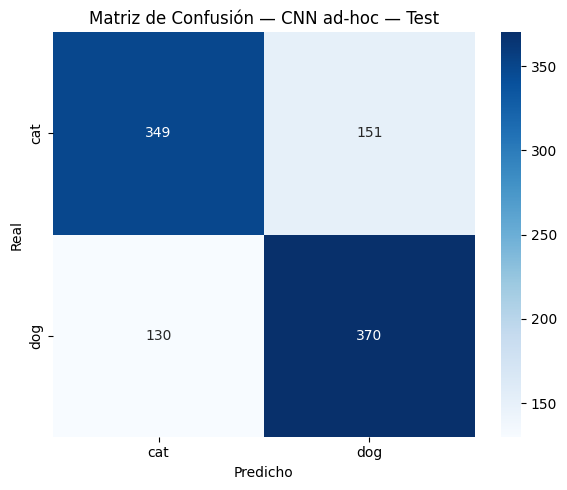

In [8]:
history_cnn = model_cnn.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
    ],
    verbose=1
)

plot_history(history_cnn, title='CNN ad-hoc')
cnn_loss, cnn_acc = evaluate_model(model_cnn, test_gen, CLASS_NAMES, title='CNN ad-hoc — Test')

## 3. Transfer Learning con MobileNetV2

Se carga MobileNetV2 preentrenado en ImageNet con los pesos congelados. Se añade una cabeza de clasificación binaria con 2 capas densas ocultas.

In [9]:
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

print(f'Capas en la base   : {len(base_model.layers)}')
print(f'Parámetros totales : {base_model.count_params():,}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Capas en la base   : 154
Parámetros totales : 2,257,984


In [10]:
def build_model(base, name='TL_MobileNetV2'):
    inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
    x = base(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    return Model(inputs, outputs, name=name)

model_tl = build_model(base_model)
model_tl.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model_tl.summary()

Model: "TL_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,618,945 (9.99 MB)

 Trainable params: 360,961 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 53s 411ms/step - accuracy: 0.9279 - loss: 0.1895 - val_accuracy: 0.9650 - val_loss: 0.0947 - learning_rate: 0.0010
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 77s 361ms/step - accuracy: 0.9609 - loss: 0.1090 - val_accuracy: 0.9633 - val_loss: 0.0867 - learning_rate: 0.0010
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 45s 416ms/step - accuracy: 0.9735 - loss: 0.0726 - val_accuracy: 0.9683 - val_loss: 0.0943 - learning_rate: 0.0010
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 82s 412ms/step - accuracy: 0.9774 - loss: 0.0588 - val_accuracy: 0.9700 - val_loss: 0.0934 - learning_rate: 0.0010
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.9866 - loss: 0.0446
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
107/107 ━━━━━━━━━━━━━━━━━━━━ 44s 415ms/step - accuracy: 0.9841 - loss: 0.0459 - val_accuracy: 0.9650 - val_loss: 0.1091 - learning_rate: 0.0010
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1950s 18s/step - accuracy: 0.990

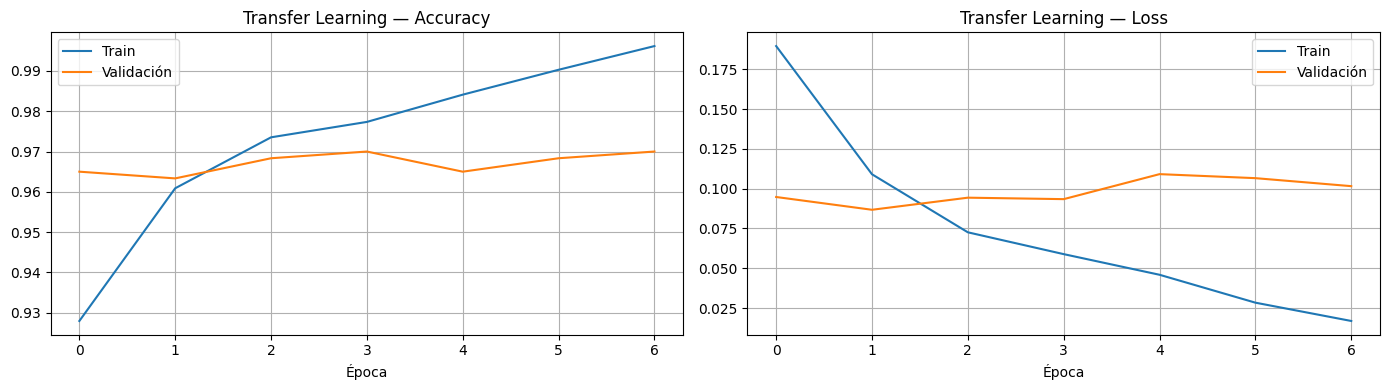


── Transfer Learning — Test ──
  Loss : 0.0910
  Acc  : 0.9560

Classification Report:
              precision    recall  f1-score   support

         cat       0.96      0.95      0.96       500
         dog       0.95      0.96      0.96       500

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



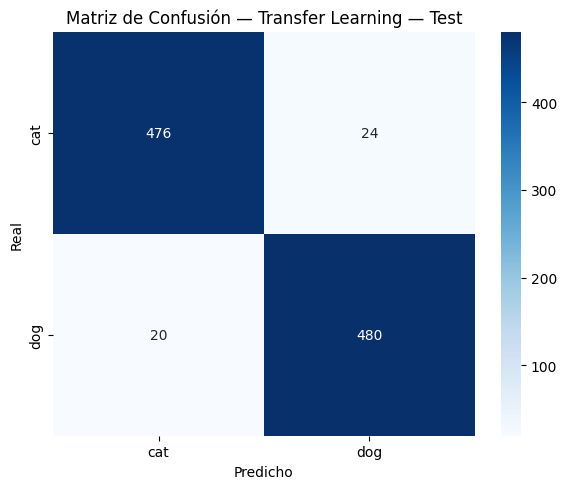

In [11]:
history_tl = model_tl.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
    ],
    verbose=1
)

plot_history(history_tl, title='Transfer Learning')
tl_loss, tl_acc = evaluate_model(model_tl, test_gen, CLASS_NAMES, title='Transfer Learning — Test')

## 4. Fine Tuning

Descongelamos las últimas 30 capas de la base y re-entrenamos con learning rate muy bajo (1e-5) para afinar los pesos sin destruir lo aprendido.

In [ ]:
base_model.trainable = True

# Congelar todo excepto las últimas 30 capas
FINE_TUNE_AT = len(base_model.layers) - 30
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

trainable = sum(1 for l in base_model.layers if l.trainable)
print(f'Capas descongeladas: {trainable} / {len(base_model.layers)}')

# Recompilar con LR muy bajo
model_tl.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_ft = model_tl.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
    ],
    verbose=1
)

plot_history(history_ft, title='Fine Tuning')
ft_loss, ft_acc = evaluate_model(model_tl, test_gen, CLASS_NAMES, title='Fine Tuning — Test')

## 5. Comparación de resultados

In [ ]:
resultados = {
    'CNN ad-hoc'       : {'Accuracy': cnn_acc, 'Loss': cnn_loss},
    'Transfer Learning': {'Accuracy': tl_acc,  'Loss': tl_loss},
    'Fine Tuning'      : {'Accuracy': ft_acc,  'Loss': ft_loss},
}

# Tabla resumen
df_resultados = pd.DataFrame(resultados).T
print(df_resultados.round(4))

# Gráfico comparativo
modelos = list(resultados.keys())
accs    = [v['Accuracy'] for v in resultados.values()]
losses  = [v['Loss']     for v in resultados.values()]
colors  = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(modelos, accs, color=colors)
axes[0].set_title('Accuracy en Test'); axes[0].set_ylim(0, 1)
for i, v in enumerate(accs):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

axes[1].bar(modelos, losses, color=colors)
axes[1].set_title('Loss en Test')
for i, v in enumerate(losses):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle('Comparación: CNN ad-hoc vs Transfer Learning vs Fine Tuning', fontsize=13)
plt.tight_layout()
plt.show()

mejor = max(resultados, key=lambda k: resultados[k]['Accuracy'])
print(f'\n✅ Mejor modelo: {mejor} — Accuracy: {resultados[mejor]["Accuracy"]:.4f}')